In [1]:
# Import necessary libraries
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR
import torchdiffeq
from scipy.optimize import minimize
import os
import time
from datetime import datetime

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModel

print("All libraries imported successfully")


All libraries imported successfully


In [2]:
# Vehicle dynamics simulation function
def simulate_vehicle(x0, u_seq, dt=0.1):
    """
    Simulate vehicle dynamics
    
    Args:
        x0: initial state [x, y, theta, v, r]
        u_seq: control sequence, shape (control_steps, 2), each step: [a, delta]
        dt: time step
    
    Returns:
        states: state sequence, shape (state_steps, 5)
    """
    state_steps = len(u_seq) + 1
    states = np.zeros((state_steps, 5))
    states[0] = x0
    
    for k in range(len(u_seq)):
        x, y, theta, v, r = states[k]
        a, delta = u_seq[k]
        
        # Euler integration
        x_next = x + dt * v * np.cos(theta)
        y_next = y + dt * v * np.sin(theta)
        theta_next = theta + dt * r
        v_next = v + dt * a
        r_next = r + dt * delta
        
        states[k+1] = [x_next, y_next, theta_next, v_next, r_next]
    
    return states


In [3]:
# Data scaler class
class Scaler:
    def __init__(self, data_min, data_max):
        self.min = data_min
        self.max = data_max
    
    def normalize(self, x):
        return 2 * (x - self.min) / (self.max - self.min) - 1
    
    def denormalize(self, x_norm):
        return (x_norm + 1) / 2 * (self.max - self.min) + self.min


In [4]:
# CLF correction related functions
def time_blow_up_function(t, T=1.0, cap=1e3):
    """
    Time blow-up function: when t→T, phi → ∞, but capped at cap
    """
    phi = 1.0 / (T - t + 1e-8)
    return min(phi, cap)

def correct_with_clf(states_phys, controls_phys, clf_params):
    """
    Correct control sequence using CLF
    
    Args:
        states_phys: physical state sequence (100,3) [x, y, theta]
        controls_phys: physical control sequence (100,2) [a, delta]
        clf_params: CLF parameters dictionary
    
    Returns:
        corrected control sequence
    """
    N = states_phys.shape[0]
    a_max = clf_params['a_max']
    d_max = clf_params['delta_max']
    λ_reg = clf_params['lambda_reg']
    β = clf_params['beta']
    mask = clf_params.get('mask', 0.0)
    t = clf_params.get('t_frac', 1.0)
    cap = clf_params.get('cap', 1e3)
    dt = clf_params.get('dt', 0.1)

    # Skip correction if t_frac < mask
    if t < mask:
        return controls_phys.copy()

    # Calculate blow_up weight
    phi = time_blow_up_function(t, T=1.0, cap=cap)
    w_state = phi / (1.0 + phi)  # ∈ (0,1)

    # Initial physical state
    x0 = np.array([states_phys[0,0],
                   states_phys[0,1],
                   states_phys[0,2],
                   0.0, 0.0])

    # Decision variable: delta_u_flat
    u0 = np.zeros(N*2, dtype=np.float32)

    def objective(delta_u_flat):
        delta_u = delta_u_flat.reshape((N,2))
        U = controls_phys + delta_u
        # Simulate first N-1 steps
        states_pred = simulate_vehicle(x0, U[:-1], dt=dt)  # (N,5)
        pos_pred = states_pred[:, :3]
        # State error
        err = pos_pred - states_phys     # (N,3)
        J_state = β * w_state * np.sum(err**2)
        J_ctrl = λ_reg * np.sum(delta_u**2)
        return J_state + J_ctrl

    # Bounds ensure phys+delta ∈ [−amax,amax]×[−dmax,dmax]
    bnds = []
    for k in range(N):
        a_phys, d_phys = controls_phys[k]
        bnds += [(-a_max - a_phys, a_max - a_phys),
                 (-d_max - d_phys, d_max - d_phys)]

    res = minimize(objective, u0, method='SLSQP', bounds=bnds,
                   options={'ftol':1e-6, 'maxiter':200})
    delta_u = res.x.reshape((N,2)).astype(np.float32)
    return controls_phys + delta_u

print("CLF correction functions defined")


CLF correction functions defined


In [5]:
# Flow Matching Model Components
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class ResidualFC(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = Mish()
    
    def forward(self, x):
        out = self.act(self.fc1(x))
        out = self.fc2(out)
        return self.act(out + x)

class UpSampler(nn.Module):
    def __init__(self, in_shape=(5,100), out_shape=(1,28,28), width=1024, depth=5):
        super().__init__()
        in_dim, out_dim = np.prod(in_shape), np.prod(out_shape)
        layers = [nn.Linear(in_dim, width), Mish()]
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.norm = nn.LayerNorm(out_dim)
        self.out_shape = out_shape
    
    def forward(self, x):
        x = x.flatten(1)
        x = self.net(x)
        x = self.norm(x)
        return x.view(x.size(0), *self.out_shape)

class DownSampler(nn.Module):
    def __init__(self, in_shape=(1,28,28), out_shape=(5,100), width=1024, depth=5):
        super().__init__()
        in_dim, out_dim = np.prod(in_shape), np.prod(out_shape)
        layers = [nn.Linear(in_dim, width), Mish()]
        for _ in range(depth-2):
            layers.append(ResidualFC(width))
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.out_shape = out_shape
    
    def forward(self, x):
        x = x.flatten(1)
        x = self.net(x)
        return x.view(x.size(0), *self.out_shape)

class ChannelAttention(nn.Module):
    def __init__(self, channels, ratio=8):
        super().__init__()
        hidden = max(channels // ratio, 1)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False), Mish(),
            nn.Conv2d(hidden, channels, 1, bias=False), nn.Sigmoid()
        )
    
    def forward(self, x):
        att = self.fc(self.avg(x) + self.max(x))
        return x * att

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=k, padding=k//2, bias=False)
    
    def forward(self, x):
        avg = x.mean(1, keepdim=True)
        mx, _ = x.max(1, keepdim=True)
        att = torch.sigmoid(self.conv(torch.cat([avg, mx], 1)))
        return x * att

class UNetWithAttention(UNetModel):
    def __init__(self, dim, num_channels, num_res_blocks, num_classes, class_cond):
        super().__init__(
            image_size=dim[-1],
            in_channels=dim[0],
            model_channels=num_channels,
            out_channels=dim[0],
            num_res_blocks=num_res_blocks,
            attention_resolutions=(16,),
            channel_mult=(1, 2, 2),
            num_classes=num_classes if class_cond else None
        )
        in_ch = dim[0]
        self.ca = ChannelAttention(in_ch)
        self.sa = SpatialAttention()
    
    def forward(self, t, x, y=None):
        feat = super().forward(t, x, y)
        feat = self.ca(feat)
        feat = self.sa(feat)
        return feat

# Create fmtorch-compatible flow model
class CarTrajectoryFlowModel(ModelWrapper):
    def __init__(self, upsampler, unet_model, downsampler):
        nn.Module.__init__(self)  # Direct nn.Module initialization
        self.upsampler = upsampler
        self.unet = unet_model
        self.downsampler = downsampler
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        # x shape: (batch_size, 5, 100)
        # t shape: (batch_size,)
        
        # Upsample to image space
        x_img = self.upsampler(x)  # (batch_size, 1, 28, 28)
        
        # Prepare dummy labels for UNet
        batch_size = x.shape[0]
        dummy_label = torch.zeros(batch_size, dtype=torch.long, device=x.device)
        
        # Through UNet
        v_img = self.unet(t, x_img, dummy_label)
        
        # Downsample back to trajectory space
        v_traj = self.downsampler(v_img)  # (batch_size, 5, 100)
        
        return v_traj

print("Flow Matching model components defined")


Flow Matching model components defined


In [6]:
# Load pre-trained Flow Matching model and setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
state_steps = 100

# Initialize Flow Matching model components
upsampler = UpSampler().to(device)
downsampler = DownSampler().to(device)
unet = UNetWithAttention(
    dim=(1, 28, 28), 
    num_channels=32, 
    num_res_blocks=2,
    num_classes=10, 
    class_cond=True
).to(device)

# Create Flow Matching model
flow_model = CarTrajectoryFlowModel(upsampler, unet, downsampler)

# Initialize fmtorch components
path = AffinePath(scheduler=CondOTScheduler())

# Load pre-trained checkpoint
ckpt_file = 'fmtorch_best_ckpt_epoch4400.pt'
if os.path.exists(ckpt_file):
    ckpt = torch.load(ckpt_file, map_location=device)
    upsampler.load_state_dict(ckpt['upsampler'])
    downsampler.load_state_dict(ckpt['downsampler'])
    unet.load_state_dict(ckpt['unet'])
    print(f"Loaded pre-trained Flow Matching model from {ckpt_file}")
else:
    print(f"Warning: {ckpt_file} not found. Using untrained model.")

# Set models to evaluation mode
upsampler.eval()
downsampler.eval()
unet.eval()

# Load reference trajectories for normalization statistics
trajectory_file = 'Car_trajectories_dataset.npy'
if os.path.exists(trajectory_file):
    trajectories = np.load(trajectory_file, allow_pickle=True)
    
    # Separate state and control scalers
    all_states = np.vstack([traj['states'][:100, :3] for traj in trajectories])  # Only position states [x, y, theta]
    all_controls = np.vstack([traj['controls'][:100] for traj in trajectories])   # Control inputs [a, delta]
    
    # State scaler (3D: x, y, theta)
    state_min, state_max = all_states.min(axis=0), all_states.max(axis=0)
    state_scaler = Scaler(state_min, state_max)
    
    # Control scaler (2D: acceleration, steering)
    control_min, control_max = all_controls.min(axis=0), all_controls.max(axis=0)
    control_scaler = Scaler(control_min, control_max)
    
    print(f"Loaded {len(trajectories)} reference trajectories for normalization")
    print(f"State ranges: {state_min} to {state_max}")
    print(f"Control ranges: {control_min} to {control_max}")
else:
    print(f"Warning: {trajectory_file} not found. Using default normalization.")
    # Default normalization ranges
    state_scaler = Scaler(np.array([-2, -2, 0]), np.array([2, 2, 2*np.pi]))
    control_scaler = Scaler(np.array([-0.5, -0.5]), np.array([0.5, 0.5]))

# CLF correction parameters
clf_params = {
    'a_max': 0.9,        # acceleration upper bound
    'delta_max': 0.9,    # steering angle upper bound
    'beta': 1e2,         # state consistency weight
    'lambda_reg': 1e2,   # control regularization weight
    'mask': 0.0,         # mask parameter
    'cap': 1e3,          # time blow-up function cap
    'dt': 0.1,           # time step
    't_frac': 1.0        # time fraction
}

print("CLF parameters setup complete:")
for key, value in clf_params.items():
    print(f"  {key}: {value}")


Loaded pre-trained Flow Matching model from fmtorch_best_ckpt_epoch4400.pt
Loaded 1000 reference trajectories for normalization
State ranges: [-1.19790784 -1.19865137  0.        ] to [1.20161734 1.19020141 1.22612348]
Control ranges: [-0.13367486 -0.18193647] to [0.1368776 0.2      ]
CLF parameters setup complete:
  a_max: 0.9
  delta_max: 0.9
  beta: 100.0
  lambda_reg: 100.0
  mask: 0.0
  cap: 1000.0
  dt: 0.1
  t_frac: 1.0


In [7]:
# Sample-based CBF-CLF Method for 2D Car Collision Avoidance

class CarObstacleAvoidance:
    """
    Car obstacle avoidance CBF-CLF controller
    Based on Car_FM.ipynb settings and dp_search_based_test.ipynb sampling methods
    """
    
    def __init__(self, obstacles=None, dt=0.1, car_length=0.001, car_width=0.001):
        """
        Initialize car obstacle avoidance controller
        
        Args:
            obstacles: obstacle list, each obstacle is {'center': [x, y], 'radius': r}
            dt: time step
            car_length, car_width: car dimensions
        """
        self.dt = dt
        self.car_length = car_length
        self.car_width = car_width
        
        # Default obstacle setting (only middle obstacle as requested)
        if obstacles is None:
            self.obstacles = [
                {'center': [0.0, 0.0], 'radius': 0.3},    # center circular obstacle only
            ]
        else:
            self.obstacles = obstacles
            
        # Control constraints (consistent with CLF_Correction_Only)
        self.a_max = 10.0      # maximum acceleration
        self.delta_max = 10.0  # maximum steering angle
        
        print(f"Car obstacle avoidance controller initialized")
        print(f"Number of obstacles: {len(self.obstacles)}")
        print(f"Vehicle size: {car_length}×{car_width}m")
        print(f"Control constraints: a∈[{-self.a_max}, {self.a_max}], δ∈[{-self.delta_max}, {self.delta_max}]")
    
    def simulate_vehicle(self, x0, u_seq, dt=None):
        """
        Vehicle dynamics simulation (consistent with CLF_Correction_Only)
        
        Args:
            x0: initial state [x, y, theta, v, r]
            u_seq: control sequence (N, 2) [a, delta]
            dt: time step
            
        Returns:
            states: state sequence (N+1, 5)
        """
        if dt is None:
            dt = self.dt
            
        N = len(u_seq)
        states = np.zeros((N + 1, 5))
        states[0] = x0
        
        for k in range(N):
            x, y, theta, v, r = states[k]
            a, delta = u_seq[k]
            
            # Vehicle dynamics (Euler integration)
            x_next = x + dt * v * np.cos(theta)
            y_next = y + dt * v * np.sin(theta)
            theta_next = theta + dt * r
            v_next = v + dt * a
            r_next = r + dt * delta
            
            states[k+1] = [x_next, y_next, theta_next, v_next, r_next]
        
        return states
    
    def cbf_constraint_value(self, state, margin=0.01):
        """
        Calculate CBF constraint value (consistent with Car_FM.ipynb: simple position detection)
        
        Args:
            state: current state [x, y, theta, v, r]
            margin: safety margin
            
        Returns:
            min_distance: minimum CBF value, >0 safe, <0 violation
        """
        # Get vehicle position (only consider x, y coordinates, consistent with Car_FM.ipynb)
        car_position = np.array([state[0], state[1]])
        min_distance = float('inf')
        
        # Check minimum distance to each obstacle (consistent with Car_FM.ipynb)
        for obstacle in self.obstacles:
            obs_center = np.array(obstacle['center'])
            obs_radius = obstacle['radius']
            
            # Calculate distance from vehicle position to obstacle center
            dist_to_center = np.linalg.norm(car_position - obs_center)
            cbf_value = dist_to_center - obs_radius - margin
            min_distance = min(min_distance, cbf_value)
        
        return min_distance
    
    def clf_lyapunov_value(self, state, target_state):
        """
        Calculate CLF Lyapunov value
        
        Args:
            state: current state [x, y, theta, v, r]
            target_state: target state [x, y, theta, v, r]
            
        Returns:
            V: Lyapunov function value
        """
        # Position error
        pos_error = np.linalg.norm(state[:2] - target_state[:2])
        
        # Angle error (handle periodicity)
        theta_error = np.abs(np.arctan2(np.sin(state[2] - target_state[2]), 
                                       np.cos(state[2] - target_state[2])))
        
        # Velocity error
        vel_error = np.abs(state[3] - target_state[3])
        
        # Weighted Lyapunov function
        V = pos_error**2 + 0.5 * theta_error**2 + 0.1 * vel_error**2
        
        return V

print("Car obstacle avoidance controller class defined")
car_controller = CarObstacleAvoidance()
    


Car obstacle avoidance controller class defined
Car obstacle avoidance controller initialized
Number of obstacles: 1
Vehicle size: 0.001×0.001m
Control constraints: a∈[-10.0, 10.0], δ∈[-10.0, 10.0]


In [8]:
# Generate trajectory using Flow Matching
def generate_trajectory_with_flow_matching():
    """
    Generate a single trajectory using Flow Matching ODE inference
    """
    print("\n=== Generating trajectory with Flow Matching ===")
    
    # Flow Matching ODE function
    def fm_ode_func(t, x_flat):
        x = x_flat.view(1, 5, state_steps)
        with torch.no_grad():
            img = upsampler(x)
            labels = torch.zeros((1,), dtype=torch.long, device=device)
            v_img = unet(t, img, labels)
            v_traj = downsampler(v_img)
        return v_traj.view(-1)
    
    # Generate trajectory from noise using ODE integration
    start_time = time.time()
    with torch.no_grad():
        x0_noise = torch.randn((1, 5, state_steps), device=device)
        t_span = torch.linspace(0., 1., 2, device=device)
        
        traj_t = torchdiffeq.odeint(
            fm_ode_func,
            x0_noise.view(-1),
            t_span,
            atol=1e-5,
            rtol=1e-5,
            method='dopri5'
        )
        x_fm_norm = traj_t[-1].view(5, state_steps).cpu().numpy()  # shape: (5, 100)
    
    generation_time = time.time() - start_time
    print(f"Flow Matching generation completed in {generation_time:.3f} seconds")
    
    # Split into states and controls, then denormalize
    states_norm = x_fm_norm[:3, :].T   # (100, 3): [x, y, theta]
    controls_norm = x_fm_norm[3:5, :].T  # (100, 2): [accel, steer]
    
    states = state_scaler.denormalize(states_norm)      # (100, 3)
    controls = control_scaler.denormalize(controls_norm)  # (100, 2)
    
    print(f"Generated trajectory shapes: states {states.shape}, controls {controls.shape}")
    
    return states, controls, generation_time

# Single trajectory CLF correction demonstration
def demonstrate_clf_correction():
    """
    Demonstrate CLF correction process on a Flow Matching generated trajectory
    """
    print("\n=== CLF Correction Demonstration ===")
    
    # Generate trajectory using Flow Matching
    states_orig, controls_orig, gen_time = generate_trajectory_with_flow_matching()
    
    # Apply CLF correction
    start_time = time.time()
    controls_corrected = correct_with_clf(states_orig, controls_orig, clf_params)
    correction_time = time.time() - start_time
    
    print(f"CLF correction completed in {correction_time:.3f} seconds")
    
    # Calculate control differences
    control_diff = controls_corrected - controls_orig
    max_diff_a = np.max(np.abs(control_diff[:, 0]))
    max_diff_delta = np.max(np.abs(control_diff[:, 1]))
    
    print(f"Maximum control corrections: acceleration {max_diff_a:.4f}, steering {max_diff_delta:.4f}")
    
    # Re-simulate trajectories
    initial_state = np.concatenate([states_orig[0], [0.0, 0.0]])  # [x, y, theta, v=0, r=0]
    
    # Simulate with original controls
    sim_states_orig = simulate_vehicle(initial_state, controls_orig[:-1], dt=clf_params['dt'])
    
    # Simulate with corrected controls  
    sim_states_corr = simulate_vehicle(initial_state, controls_corrected[:-1], dt=clf_params['dt'])
    
    # Calculate RMSE
    def rmse(a, b):
        return np.sqrt(np.mean(np.sum((a[:, :2] - b[:, :2])**2, axis=1)))
    
    rmse_orig = rmse(states_orig, sim_states_orig[:, :3])
    rmse_corr = rmse(states_orig, sim_states_corr[:, :3])
    
    improvement = 0 if rmse_orig == 0 else ((rmse_orig - rmse_corr) / rmse_orig * 100)
    
    print(f"RMSE (original): {rmse_orig:.4f} m")
    print(f"RMSE (corrected): {rmse_corr:.4f} m")
    print(f"RMSE improvement: {improvement:.1f}%")
    
    return {
        'states_orig': states_orig,
        'controls_orig': controls_orig,
        'controls_corrected': controls_corrected,
        'sim_states_orig': sim_states_orig,
        'sim_states_corr': sim_states_corr,
        'rmse_orig': rmse_orig,
        'rmse_corr': rmse_corr,
        'correction_time': correction_time,
        'generation_time': gen_time
    }

# Run single demonstration
demo_result = demonstrate_clf_correction()



=== CLF Correction Demonstration ===

=== Generating trajectory with Flow Matching ===
Flow Matching generation completed in 1.682 seconds
Generated trajectory shapes: states (100, 3), controls (100, 2)
CLF correction completed in 1.122 seconds
Maximum control corrections: acceleration 0.0070, steering 0.0162
RMSE (original): 0.0520 m
RMSE (corrected): 0.0444 m
RMSE improvement: 14.6%


In [9]:
# Improved CBF-CLF Method: Control-Only Sampling with Dynamic State Generation

def improved_cbf_clf_control_sampling(car_controller, original_states, original_controls,
                                    n_samples=1000, max_iterations=300,
                                    state_similarity_weight=50.0,     # State similarity to original trajectory
                                    control_smoothness_weight=10.0,   # Control smoothness
                                    state_smoothness_weight=20.0,     # State smoothness
                                    collision_avoidance_weight=1000.0, # Collision avoidance (high weight)
                                    control_reg_weight=1.0,           # Control regularization
                                    random_seed=42):
    """
    Improved CBF-CLF method: control correction sampling only, with cost evaluation via dynamics-based state generation

    Args:
        car_controller: vehicle controller
        original_states: original state trajectory (T, 3) [x, y, theta]
        original_controls: original control sequence (T, 2) [a, delta]
        Various weight parameters

    Returns:
        optimized_controls: optimized control sequence
        generated_states: state trajectory generated by optimized controls
        optimization_info: optimization information
    """
    print(f"\n=== Improved CBF-CLF Method: Control-Only Sampling + Dynamic State Generation ===")
    print(f"Trajectory length: {len(original_controls)} steps")
    print(f"Samples per iteration: {n_samples}, Max iterations: {max_iterations}")
    print(f"Weight settings:")
    print(f"  State similarity: {state_similarity_weight}")
    print(f"  Control smoothness: {control_smoothness_weight}")
    print(f"  State smoothness: {state_smoothness_weight}")
    print(f"  Collision avoidance: {collision_avoidance_weight}")
    print(f"  Control regularization: {control_reg_weight}")

    np.random.seed(random_seed)
    T = len(original_controls)

    # Initial state setup
    x0 = np.concatenate([original_states[0], [0.0, 0.0]])  # [x, y, theta, v=0, r=0]

    # Initialize best solution
    best_control_corrections = np.zeros_like(original_controls)
    best_controls = original_controls.copy()
    best_cost = float('inf')

    def evaluate_control_corrections(control_corrections):
        """
        Evaluate the total cost of control corrections.
        Core idea: use corrected controls + dynamics to directly generate states, avoiding state-action mismatch.
        """
        try:
            # 1. Apply control corrections
            corrected_controls = original_controls + control_corrections

            # Apply control constraints
            corrected_controls = np.clip(corrected_controls,
                                       [-car_controller.a_max, -car_controller.delta_max],
                                       [car_controller.a_max, car_controller.delta_max])

            # 2. Generate state trajectory via dynamics simulation
            generated_states = car_controller.simulate_vehicle(x0, corrected_controls[:-1])

            # Ensure state trajectory length matches
            if len(generated_states) > len(original_states):
                generated_states = generated_states[:len(original_states)]

            # === Cost function calculation ===

            # 1. State similarity cost: similarity between generated and original states
            state_similarity_cost = 0.0
            for t in range(len(original_states)):
                if t < len(generated_states):
                    # Position difference (x, y)
                    pos_diff = np.linalg.norm(generated_states[t][:2] - original_states[t][:2])
                    # Angle difference (handle periodicity)
                    angle_diff = np.abs(np.arctan2(np.sin(generated_states[t][2] - original_states[t][2]),
                                                   np.cos(generated_states[t][2] - original_states[t][2])))
                    state_similarity_cost += pos_diff**2 + 0.5 * angle_diff**2

            # 2. Control smoothness cost: rate of change of control inputs
            control_smoothness_cost = 0.0
            for t in range(1, len(corrected_controls)):
                control_diff = corrected_controls[t] - corrected_controls[t-1]
                control_smoothness_cost += np.sum(control_diff**2)

            # 3. State smoothness cost: rate of change of generated states
            state_smoothness_cost = 0.0
            for t in range(1, len(generated_states)):
                if t < len(generated_states):
                    # Position smoothness
                    pos_diff = np.linalg.norm(generated_states[t][:2] - generated_states[t-1][:2])
                    # Angle smoothness
                    angle_diff = np.abs(generated_states[t][2] - generated_states[t-1][2])
                    state_smoothness_cost += pos_diff**2 + 0.1 * angle_diff**2

            # 4. Collision cost: penalty for CBF constraint violation (high weight)
            collision_cost = 0.0
            collision_violations = 0
            for t in range(len(generated_states)):
                cbf_value = car_controller.cbf_constraint_value(generated_states[t])
                if cbf_value < 0:  # Safety constraint violated
                    collision_cost += (-cbf_value)**2
                    collision_violations += 1
                else:
                    # Soft constraint: higher cost when closer to obstacle
                    safety_margin = 0.01  # Safety margin
                    if cbf_value < safety_margin:
                        collision_cost += (safety_margin - cbf_value)**2 * 0.1

            # 5. Control regularization cost: prevent excessive control corrections
            control_reg_cost = np.sum(control_corrections**2)

            # 6. Total cost calculation
            total_cost = (state_similarity_weight * state_similarity_cost +
                         control_smoothness_weight * control_smoothness_cost +
                         state_smoothness_weight * state_smoothness_cost +
                         collision_avoidance_weight * collision_cost +
                         control_reg_weight * control_reg_cost)

            return total_cost, collision_violations, {
                'state_similarity': state_similarity_cost,
                'control_smoothness': control_smoothness_cost,
                'state_smoothness': state_smoothness_cost,
                'collision_avoidance': collision_cost,
                'control_regularization': control_reg_cost,
                'generated_states': generated_states
            }

        except Exception as e:
            print(f"Evaluation error: {e}")
            return float('inf'), T, None

    # Evaluate original trajectory
    original_result = evaluate_control_corrections(np.zeros_like(original_controls))
    original_cost, original_violations = original_result[0], original_result[1]
    original_breakdown = original_result[2]
    best_cost = original_cost

    print(f"\nOriginal trajectory cost analysis:")
    print(f"  Total cost: {original_cost:.3f}")
    if original_breakdown:
        print(f"  State similarity: {original_breakdown['state_similarity']:.3f}")
        print(f"  Control smoothness: {original_breakdown['control_smoothness']:.3f}")
        print(f"  State smoothness: {original_breakdown['state_smoothness']:.3f}")
        print(f"  Collision cost: {original_breakdown['collision_avoidance']:.3f}")
        print(f"  Control regularization: {original_breakdown['control_regularization']:.3f}")
    print(f"Original trajectory collision count: {original_violations}/{T}")

    # Optimization history
    optimization_history = {
        'costs': [],
        'collision_violations': [],
        'best_costs': [],
        'acceptance_rates': []
    }

    start_time = time.time()
    print(f"\nStarting control correction sampling optimization...")

    for iteration in range(max_iterations):
        iteration_costs = []
        iteration_corrections = []
        accepted_samples = 0

        for sample_idx in range(n_samples):
            if sample_idx == 0:
                # First sample uses current best solution
                candidate_corrections = best_control_corrections.copy()
            else:
                # Sampling strategy: diverse control corrections
                progress = iteration / max_iterations
                noise_std = 0.05 * (1 - 0.7 * progress)  # Noise decreases with iterations

                if sample_idx < n_samples // 4:
                    # Strategy 1: global Gaussian noise
                    candidate_corrections = np.random.normal(0, noise_std, original_controls.shape)
                elif sample_idx < n_samples // 2:
                    # Strategy 2: local perturbation around current best
                    candidate_corrections = best_control_corrections + np.random.normal(0, noise_std/2, original_controls.shape)
                elif sample_idx < 3 * n_samples // 4:
                    # Strategy 3: time-local correction (modify only part of the trajectory)
                    candidate_corrections = best_control_corrections.copy()
                    n_modify = max(1, T // 8)
                    modify_indices = np.random.choice(T, n_modify, replace=False)
                    candidate_corrections[modify_indices] += np.random.normal(0, noise_std * 2, (n_modify, 2))
                else:
                    # Strategy 4: gradient-inspired correction (towards reducing collision risk)
                    candidate_corrections = best_control_corrections.copy()
                    # Increase correction at time steps with high collision risk
                    risk_weights = np.ones(T)
                    if original_breakdown and 'generated_states' in original_breakdown:
                        for t, state in enumerate(original_breakdown['generated_states']):
                            if t < T:
                                cbf_val = car_controller.cbf_constraint_value(state)
                                if cbf_val < 0.3:  # Near danger zone
                                    risk_weights[t] = 3.0

                    noise = np.random.normal(0, noise_std, original_controls.shape)
                    candidate_corrections += noise * risk_weights.reshape(-1, 1)

            # Evaluate candidate solution
            result = evaluate_control_corrections(candidate_corrections)
            cost, violations = result[0], result[1]

            iteration_costs.append(cost)
            iteration_corrections.append(candidate_corrections.copy())

            # Update best solution
            if cost < best_cost:
                best_cost = cost
                best_control_corrections = candidate_corrections.copy()
                best_controls = original_controls + candidate_corrections
                accepted_samples += 1

        # Record history
        min_cost = min(iteration_costs)
        min_idx = np.argmin(iteration_costs)
        min_violations = evaluate_control_corrections(iteration_corrections[min_idx])[1]

        optimization_history['costs'].append(min_cost)
        optimization_history['collision_violations'].append(min_violations)
        optimization_history['best_costs'].append(best_cost)
        optimization_history['acceptance_rates'].append(accepted_samples / n_samples)

        # Progress report
        if (iteration + 1) % 50 == 0:
            elapsed_time = time.time() - start_time
            eta = elapsed_time / (iteration + 1) * (max_iterations - iteration - 1)
            improvement = (original_cost - best_cost) / original_cost * 100 if original_cost > 0 else 0

            print(f"  Iteration {iteration+1:3d}/{max_iterations}: "
                  f"Best cost {best_cost:.3f} ({improvement:+.1f}%), "
                  f"Collisions {min_violations}/{T}, "
                  f"Acceptance rate {accepted_samples/n_samples:.1%}, "
                  f"ETA {eta:.1f}s")

    total_time = time.time() - start_time

    # Final evaluation
    final_result = evaluate_control_corrections(best_control_corrections)
    final_cost, final_violations = final_result[0], final_result[1]
    final_breakdown = final_result[2]
    improvement = (original_cost - final_cost) / original_cost * 100 if original_cost > 0 else 0

    print(f"\n=== Improved CBF-CLF Optimization Complete ===")
    print(f"Total optimization time: {total_time:.1f}s")
    print(f"Cost improvement: {original_cost:.3f} → {final_cost:.3f} ({improvement:+.1f}%)")
    print(f"Collision reduction: {original_violations} → {final_violations} times")

    if final_breakdown:
        print(f"Final cost breakdown:")
        print(f"  State similarity: {final_breakdown['state_similarity']:.3f}")
        print(f"  Control smoothness: {final_breakdown['control_smoothness']:.3f}")
        print(f"  State smoothness: {final_breakdown['state_smoothness']:.3f}")
        print(f"  Collision cost: {final_breakdown['collision_avoidance']:.3f}")
        print(f"  Control regularization: {final_breakdown['control_regularization']:.3f}")

    optimization_info = {
        'original_cost': original_cost,
        'final_cost': final_cost,
        'improvement_percentage': improvement,
        'original_violations': original_violations,
        'final_violations': final_violations,
        'optimization_time': total_time,
        'optimization_history': optimization_history,
        'final_breakdown': final_breakdown,
        'success': final_violations < original_violations or final_cost < original_cost * 0.9
    }

    # Generate final state trajectory
    final_generated_states = final_breakdown['generated_states'] if final_breakdown else None

    return best_controls, final_generated_states, optimization_info

print("Improved CBF-CLF control sampling method has been defined.")


Improved CBF-CLF control sampling method has been defined.


In [10]:
def visualize_improved_cbf_clf_results(car_controller, original_states, original_controls,
                                     optimized_controls, optimized_states, optimization_info):
    """
    Visualize improved CBF-CLF results: original states vs. corrected/generated states
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Trajectory comparison (XY plane)
    ax = axes[0, 0]
    
    # Draw obstacles
    for i, obs in enumerate(car_controller.obstacles):
        circle = plt.Circle(obs['center'], obs['radius'], 
                          color='red', alpha=0.3, label='Obstacle' if i == 0 else "")
        ax.add_patch(circle)
    
    # Draw trajectories
    ax.plot(original_states[:, 0], original_states[:, 1], 'b-', 
           linewidth=3, alpha=0.7, label='Original Trajectory')
    ax.plot(optimized_states[:, 0], optimized_states[:, 1], 'g-', 
           linewidth=3, label='CBF-CLF Optimized Trajectory')
    
    # Start and goal
    ax.scatter(original_states[0, 0], original_states[0, 1], 
              c='blue', s=150, marker='o', label='Start', zorder=5)
    ax.scatter(original_states[-1, 0], original_states[-1, 1], 
              c='red', s=150, marker='*', label='Goal', zorder=5)
    
    ax.set_xlabel('X Position [m]')
    ax.set_ylabel('Y Position [m]')
    ax.set_title('Vehicle Trajectory Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    
    # 2. Control input comparison - Acceleration
    ax = axes[0, 1]
    time_axis = np.arange(len(original_controls)) * car_controller.dt
    ax.plot(time_axis, original_controls[:, 0], 'b-', linewidth=2, alpha=0.7, label='Original Acceleration')
    ax.plot(time_axis, optimized_controls[:, 0], 'g-', linewidth=2, label='Optimized Acceleration')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Acceleration [m/s²]')
    ax.set_title('Acceleration Control Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Control input comparison - Steering angle
    ax = axes[0, 2]
    ax.plot(time_axis, original_controls[:, 1], 'b-', linewidth=2, alpha=0.7, label='Original Steering')
    ax.plot(time_axis, optimized_controls[:, 1], 'g-', linewidth=2, label='Optimized Steering')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Steering Angle [rad]')
    ax.set_title('Steering Control Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. CBF value over time
    ax = axes[1, 0]
    
    # Compute CBF values
    x0 = np.concatenate([original_states[0], [0.0, 0.0]])
    sim_states_orig = car_controller.simulate_vehicle(x0, original_controls[:-1])
    sim_states_opt = optimized_states
    
    cbf_orig = [car_controller.cbf_constraint_value(state) for state in sim_states_orig]
    cbf_opt = [car_controller.cbf_constraint_value(state) for state in sim_states_opt]
    
    time_states = np.arange(len(cbf_orig)) * car_controller.dt
    
    ax.plot(time_states, cbf_orig, 'b-', linewidth=2, alpha=0.7, label='Original CBF')
    ax.plot(time_states[:len(cbf_opt)], cbf_opt, 'g-', linewidth=2, label='Optimized CBF')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Safety Boundary')
    ax.fill_between(time_states, -0.5, 0, alpha=0.2, color='red', label='Danger Zone')
    
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('CBF Value [m]')
    ax.set_title('Safety Constraint (CBF) Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. State error analysis
    ax = axes[1, 1]
    
    # Compute position errors
    pos_errors_orig = [0.0]  # Original trajectory error with itself is 0
    pos_errors_opt = []
    
    for t in range(len(original_states)):
        if t < len(optimized_states):
            pos_error = np.linalg.norm(optimized_states[t][:2] - original_states[t][:2])
            pos_errors_opt.append(pos_error)
        else:
            pos_errors_opt.append(0)
    
    pos_errors_orig = [0] * len(pos_errors_opt)  # Original trajectory error always 0
    time_states_short = np.arange(len(pos_errors_opt)) * car_controller.dt
    
    ax.plot(time_states_short, pos_errors_orig, 'b-', linewidth=2, alpha=0.7, label='Original Trajectory Error')
    ax.plot(time_states_short, pos_errors_opt, 'g-', linewidth=2, label='Optimized vs. Original Difference')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Position Error [m]')
    ax.set_title('Trajectory Tracking Error')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Optimization convergence curve
    ax = axes[1, 2]
    
    if 'optimization_history' in optimization_info:
        history = optimization_info['optimization_history']
        iterations = range(1, len(history['best_costs']) + 1)
        
        ax.plot(iterations, history['best_costs'], 'g-', linewidth=2, label='Best Cost')
        ax.plot(iterations, history['costs'], 'g--', alpha=0.5, label='Current Iteration Best')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Cost Value')
        ax.set_title('Optimization Convergence')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical analysis
    orig_violations = sum(1 for cbf in cbf_orig if cbf < 0)
    opt_violations = sum(1 for cbf in cbf_opt if cbf < 0)
    
    print(f"\n=== Improved CBF-CLF Method Performance Analysis ===")
    print(f"Collision Violation Statistics:")
    print(f"  Original Trajectory: {orig_violations}/{len(cbf_orig)} times ({orig_violations/len(cbf_orig)*100:.1f}%)")
    print(f"  Optimized Trajectory: {opt_violations}/{len(cbf_opt)} times ({opt_violations/len(cbf_opt)*100:.1f}%)")
    print(f"  Improvement: {orig_violations - opt_violations} times reduced")
    
    print(f"\nControl Correction Statistics:")
    control_diff = optimized_controls - original_controls
    print(f"  Mean Acceleration Correction: {np.mean(np.abs(control_diff[:, 0])):.4f} m/s²")
    print(f"  Mean Steering Correction: {np.mean(np.abs(control_diff[:, 1])):.4f} rad")
    print(f"  Max Acceleration Correction: {np.max(np.abs(control_diff[:, 0])):.4f} m/s²")
    print(f"  Max Steering Correction: {np.max(np.abs(control_diff[:, 1])):.4f} rad")
    
    print(f"\nTrajectory Deviation Statistics:")
    max_pos_error = np.max(pos_errors_opt)
    avg_pos_error = np.mean(pos_errors_opt)
    print(f"  Mean Position Deviation: {avg_pos_error:.4f} m")
    print(f"  Max Position Deviation: {max_pos_error:.4f} m")
    
    print(f"\nMethod Advantages:")
    print(f"  ✓ State-Action Consistency: States are fully generated by control + dynamics")
    print(f"  ✓ Multi-objective Optimization: Safety + Tracking + Smoothness")
    print(f"  ✓ Flexible Control: Only sample control corrections")
    print(f"  ✓ Avoid Mismatch: No state-action inconsistency problem")

print("可视化函数已定义完成")




# Verify whether the optimized state sequence is consistent with the state sequence resimulated from the controls
def verify_state_control_consistency(car_controller, original_states, optimized_controls, optimized_states):
    """
    Verify whether the optimized state sequence is consistent with the state sequence resimulated from the controls
    
    Args:
        car_controller: vehicle controller
        original_states: original state sequence
        optimized_controls: optimized control sequence
        optimized_states: optimized state sequence (returned by improved_cbf_clf_control_sampling)
    """
    print("\n=== Verifying State-Control Consistency ===")
    
    # Resimulate state sequence from initial state and optimized controls
    x0 = np.concatenate([original_states[0], [0.0, 0.0]])  # [x, y, theta, v=0, r=0]
    resimulated_states = car_controller.simulate_vehicle(x0, optimized_controls[:-1])
    
    # Compute the difference between the two state sequences
    state_diff = []
    for t in range(min(len(optimized_states), len(resimulated_states))):
        # Compute position difference (x, y)
        pos_diff = np.linalg.norm(optimized_states[t][:2] - resimulated_states[t][:2])
        # Compute angle difference (theta)
        angle_diff = np.abs(np.arctan2(np.sin(optimized_states[t][2] - resimulated_states[t][2]),
                                      np.cos(optimized_states[t][2] - resimulated_states[t][2])))
        state_diff.append([pos_diff, angle_diff])
    
    state_diff = np.array(state_diff)
    
    # Statistical analysis
    max_pos_diff = np.max(state_diff[:, 0])
    max_angle_diff = np.max(state_diff[:, 1])
    avg_pos_diff = np.mean(state_diff[:, 0])
    avg_angle_diff = np.mean(state_diff[:, 1])
    
    print(f"State sequence length comparison: optimized={len(optimized_states)}, resimulated={len(resimulated_states)}")
    print(f"Position difference (x, y): max={max_pos_diff:.8f}m, mean={avg_pos_diff:.8f}m")
    print(f"Angle difference (theta): max={max_angle_diff:.8f}rad, mean={avg_angle_diff:.8f}rad")
    
    # Determine consistency (using small threshold)
    is_consistent = max_pos_diff < 1e-6 and max_angle_diff < 1e-6
    print(f"State-control consistency: {'✓ Consistent' if is_consistent else '✗ Inconsistent'}")
    
    # Visualization comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Trajectory comparison
    ax = axes[0]
    ax.plot(optimized_states[:, 0], optimized_states[:, 1], 'g-', 
           linewidth=2, label='Optimized State Sequence')
    ax.plot(resimulated_states[:, 0], resimulated_states[:, 1], 'r--', 
           linewidth=2, alpha=0.7, label='Resimulated State Sequence')
    
    # Draw obstacles
    for i, obs in enumerate(car_controller.obstacles):
        circle = plt.Circle(obs['center'], obs['radius'], 
                          color='blue', alpha=0.3, label='Obstacle' if i == 0 else "")
        ax.add_patch(circle)
    
    ax.set_xlabel('X Position [m]')
    ax.set_ylabel('Y Position [m]')
    ax.set_title('Trajectory Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    
    # 2. Position difference over time
    ax = axes[1]
    time_axis = np.arange(len(state_diff)) * car_controller.dt
    ax.plot(time_axis, state_diff[:, 0], 'b-', linewidth=2)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Position Difference [m]')
    ax.set_title('Position Difference Over Time')
    ax.grid(True, alpha=0.3)
    if max_pos_diff > 0:
        ax.set_yscale('log')  # Log scale for better visualization of small differences
    
    # 3. Angle difference over time
    ax = axes[2]
    ax.plot(time_axis, state_diff[:, 1], 'r-', linewidth=2)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Angle Difference [rad]')
    ax.set_title('Angle Difference Over Time')
    ax.grid(True, alpha=0.3)
    if max_angle_diff > 0:
        ax.set_yscale('log')  # Log scale for better visualization of small differences
    
    plt.tight_layout()
    plt.show()
    
    return is_consistent, resimulated_states

可视化函数已定义完成


In [11]:
# Verify whether the optimized state sequence is consistent with the resimulated state sequence from controls
def verify_state_control_consistency(car_controller, original_states, optimized_controls, optimized_states):
    """
    Verify whether the optimized state sequence is consistent with the resimulated state sequence from controls
    
    Args:
        car_controller: vehicle controller
        original_states: original state sequence
        optimized_controls: optimized control sequence
        optimized_states: optimized state sequence (returned by improved_cbf_clf_control_sampling)
    """
    print("\n=== Verifying state-control consistency ===")
    
    # Check if the starting point is consistent
    print(f"Optimized state start point: {optimized_states[0]}")
    
    # Resimulate state sequence from starting state and optimized controls
    # Note: check if the starting point is correct
    x0_orig = np.concatenate([original_states[0], [0.0, 0.0]])  # [x, y, theta, v=0, r=0]
    print(f"Original start point (extended): {x0_orig}")
    
    # Check if the starting point of optimized_states is consistent with the original starting point
    if len(optimized_states[0]) == 5:  # Full state [x, y, theta, v, r]
        x0_opt = optimized_states[0]
        print(f"Optimized state start point (full): {x0_opt}")
    else:  # Partial state [x, y, theta]
        x0_opt = np.concatenate([optimized_states[0], [0.0, 0.0]])
        print(f"Optimized state start point (extended): {x0_opt}")
    
    # Resimulate using the starting point of the optimized state
    if len(optimized_states[0]) == 5:
        resimulated_states = car_controller.simulate_vehicle(optimized_states[0], optimized_controls[:-1])
        print("Resimulate using the full optimized state start point")
    else:
        resimulated_states = car_controller.simulate_vehicle(x0_orig, optimized_controls[:-1])
        print("Resimulate using the extended original state start point")
    
    # Print the first few states for comparison
    print("\nFirst 5 state comparisons:")
    for i in range(min(5, len(optimized_states), len(resimulated_states))):
        print(f"Timestep {i}:")
        print(f"  Optimized state: {optimized_states[i]}")
        print(f"  Resimulated: {resimulated_states[i]}")
    
    # Compute the difference between the two state sequences
    state_diff = []
    for t in range(min(len(optimized_states), len(resimulated_states))):
        # Compute position difference (x, y)
        pos_diff = np.linalg.norm(optimized_states[t][:2] - resimulated_states[t][:2])
        # Compute angle difference (theta)
        angle_diff = np.abs(np.arctan2(np.sin(optimized_states[t][2] - resimulated_states[t][2]),
                                      np.cos(optimized_states[t][2] - resimulated_states[t][2])))
        state_diff.append([pos_diff, angle_diff])
    
    state_diff = np.array(state_diff)
    
    # Statistical analysis
    max_pos_diff = np.max(state_diff[:, 0])
    max_angle_diff = np.max(state_diff[:, 1])
    avg_pos_diff = np.mean(state_diff[:, 0])
    avg_angle_diff = np.mean(state_diff[:, 1])
    
    print(f"\nState sequence length comparison: optimized={len(optimized_states)}, resimulated={len(resimulated_states)}")
    print(f"Position difference (x, y): max={max_pos_diff:.8f}m, mean={avg_pos_diff:.8f}m")
    print(f"Angle difference (theta): max={max_angle_diff:.8f}rad, mean={avg_angle_diff:.8f}rad")
    
    # Determine consistency (using small threshold)
    is_consistent = max_pos_diff < 1e-6 and max_angle_diff < 1e-6
    print(f"State-control consistency: {'✓ Consistent' if is_consistent else '✗ Inconsistent'}")
    
    # Visualization comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Trajectory comparison
    ax = axes[0]
    ax.plot(optimized_states[:, 0], optimized_states[:, 1], 'g-', 
           linewidth=2, label='Optimized State Sequence')
    ax.plot(resimulated_states[:, 0], resimulated_states[:, 1], 'r--', 
           linewidth=2, alpha=0.7, label='Resimulated State Sequence')
    
    # Draw starting points
    ax.scatter(optimized_states[0, 0], optimized_states[0, 1], 
              c='green', s=100, marker='o', label='Optimized Start')
    ax.scatter(resimulated_states[0, 0], resimulated_states[0, 1], 
              c='red', s=100, marker='x', label='Resimulated Start')
    
    # Draw obstacles
    for i, obs in enumerate(car_controller.obstacles):
        circle = plt.Circle(obs['center'], obs['radius'], 
                          color='blue', alpha=0.3, label='Obstacle' if i == 0 else "")
        ax.add_patch(circle)
    
    ax.set_xlabel('X Position [m]')
    ax.set_ylabel('Y Position [m]')
    ax.set_title('Trajectory Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    
    # 2. Position difference over time
    ax = axes[1]
    time_axis = np.arange(len(state_diff)) * car_controller.dt
    ax.plot(time_axis, state_diff[:, 0], 'b-', linewidth=2)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Position Difference [m]')
    ax.set_title('Position Difference Over Time')
    ax.grid(True, alpha=0.3)
    if max_pos_diff > 0:
        ax.set_yscale('log')  # Log scale for better visualization of small differences
    
    # 3. Angle difference over time
    ax = axes[2]
    ax.plot(time_axis, state_diff[:, 1], 'r-', linewidth=2)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Angle Difference [rad]')
    ax.set_title('Angle Difference Over Time')
    ax.grid(True, alpha=0.3)
    if max_angle_diff > 0:
        ax.set_yscale('log')  # Log scale for better visualization of small differences
    
    plt.tight_layout()
    plt.show()
    
    return is_consistent, resimulated_states

# Check the state generation logic in improved_cbf_clf_control_sampling function
def analyze_improved_cbf_clf_logic():
    """Analyze the state generation logic in improved_cbf_clf_control_sampling function"""
    print("\n=== Analyzing state generation logic in improved_cbf_clf_control_sampling function ===")
    
    # Check relevant code in evaluate_control_corrections function
    print("In evaluate_control_corrections function:")
    print("1. Apply control corrections: corrected_controls = original_controls + control_corrections")
    print("2. Generate state trajectory: generated_states = car_controller.simulate_vehicle(x0, corrected_controls[:-1])")
    print("3. x0 = np.concatenate([original_states[0], [0.0, 0.0]])  # [x, y, theta, v=0, r=0]")
    
    print("\nWhen returning from the function:")
    print("return best_controls, final_generated_states, optimization_info")
    print("where final_generated_states = final_breakdown['generated_states'] if final_breakdown else None")
    
    print("\nConclusion:")
    print("1. The optimized state is generated by the vehicle dynamics model from the original start point and optimized controls")
    print("2. If the trajectory is offset, it may be due to:")
    print("   a. The start point of the optimized state is inconsistent with the start point used for resimulation")
    print("   b. Numerical error accumulation during optimization")
    print("   c. Control sequence truncation issue (controls[:-1])")




In [12]:
# # Batch generate CBF-CLF optimization results and save as npz file
# def batch_generate_cbf_clf_results(n_samples=100, save_path='cbf_clf_batch_results.npz'):
#     """
#     Batch generate CBF-CLF optimization results and save as npz file

#     Args:
#         n_samples: number of samples
#         save_path: save path
#     """
#     print(f"\n=== Batch generating CBF-CLF optimization results ({n_samples} samples in total) ===")

#     # Create car controller
#     car_controller = CarObstacleAvoidance()

#     # Initialize result storage
#     results = {
#         'original_states': [],
#         'original_controls': [],
#         'optimized_states': [],
#         'optimized_controls': [],
#         'optimization_info': [],
#         'sample_id': []
#     }

#     # Batch generation and optimization
#     start_time = time.time()
#     successful_samples = 0

#     for i in range(n_samples):
#         sample_start_time = time.time()
#         print(f"\n--- Sample {i+1}/{n_samples} ---")

#         try:
#             # Generate trajectory
#             states_orig, controls_orig, _ = generate_trajectory_with_flow_matching()

#             # Apply CBF-CLF optimization
#             print(f"Applying CBF-CLF optimization...")
#             optimized_controls, optimized_states, optimization_info = improved_cbf_clf_control_sampling(
#                 car_controller, states_orig, controls_orig,
#                 n_samples=500,  # Reduce sample size for faster processing
#                 max_iterations=100,  # Reduce iterations for faster processing
#                 state_similarity_weight=50.0,
#                 control_smoothness_weight=10.0,
#                 state_smoothness_weight=20.0,
#                 collision_avoidance_weight=1000.0,
#                 control_reg_weight=1.0,
#                 random_seed=42+i  # Different random seed
#             )

#             # Store results
#             results['original_states'].append(states_orig)
#             results['original_controls'].append(controls_orig)
#             results['optimized_states'].append(optimized_states)
#             results['optimized_controls'].append(optimized_controls)
#             results['optimization_info'].append(optimization_info)
#             results['sample_id'].append(i)

#             successful_samples += 1

#             # Calculate and display progress
#             sample_time = time.time() - sample_start_time
#             elapsed_time = time.time() - start_time
#             avg_time_per_sample = elapsed_time / (i + 1)
#             eta = avg_time_per_sample * (n_samples - i - 1)

#             print(f"Sample {i+1} finished, time used: {sample_time:.1f}s")
#             print(f"Progress: {i+1}/{n_samples} ({(i+1)/n_samples*100:.1f}%), estimated remaining time: {eta:.1f}s")

#             # Save intermediate results every 10 samples
#             if (i + 1) % 10 == 0:
#                 temp_save_path = save_path.replace('.npz', f'_temp_{i+1}.npz')
#                 np.savez_compressed(
#                     temp_save_path,
#                     original_states=np.array(results['original_states'], dtype=object),
#                     original_controls=np.array(results['original_controls'], dtype=object),
#                     optimized_states=np.array(results['optimized_states'], dtype=object),
#                     optimized_controls=np.array(results['optimized_controls'], dtype=object),
#                     optimization_info=np.array(results['optimization_info'], dtype=object),
#                     sample_id=np.array(results['sample_id'])
#                 )
#                 print(f"Intermediate results saved to {temp_save_path}")

#         except Exception as e:
#             print(f"Sample {i+1} generation failed: {e}")

#     # Save final results
#     np.savez_compressed(
#         save_path,
#         original_states=np.array(results['original_states'], dtype=object),
#         original_controls=np.array(results['original_controls'], dtype=object),
#         optimized_states=np.array(results['optimized_states'], dtype=object),
#         optimized_controls=np.array(results['optimized_controls'], dtype=object),
#         optimization_info=np.array(results['optimization_info'], dtype=object),
#         sample_id=np.array(results['sample_id'])
#     )

#     total_time = time.time() - start_time

#     print(f"\n=== Batch generation finished ===")
#     print(f"Total samples: {n_samples}")
#     print(f"Successful samples: {successful_samples}")
#     print(f"Total time used: {total_time:.1f}s")
#     print(f"Average time per sample: {total_time/successful_samples:.1f}s")
#     print(f"Results saved to: {save_path}")

#     return results

# # Batch generate and analyze CBF-CLF results
# def analyze_batch_results(results_path='cbf_clf_batch_results.npz'):
#     """
#     Analyze batch generated CBF-CLF optimization results

#     Args:
#         results_path: result file path
#     """
#     print(f"\n=== Analyzing batch CBF-CLF optimization results ===")

#     # Load results
#     print(f"Loading results from {results_path} ...")
#     data = np.load(results_path, allow_pickle=True)

#     original_states = data['original_states']
#     original_controls = data['original_controls']
#     optimized_states = data['optimized_states']
#     optimized_controls = data['optimized_controls']
#     optimization_info = data['optimization_info']
#     sample_id = data['sample_id']

#     n_samples = len(sample_id)
#     print(f"Loaded {n_samples} samples")

#     # Create car controller for analysis
#     car_controller = CarObstacleAvoidance()

#     # Analyze results
#     improvement_percentages = []
#     original_violations_count = []
#     optimized_violations_count = []
#     control_diff_mean = []
#     position_diff_mean = []

#     for i in range(n_samples):
#         # Get current sample
#         orig_states = original_states[i]
#         orig_controls = original_controls[i]
#         opt_states = optimized_states[i]
#         opt_controls = optimized_controls[i]
#         opt_info = optimization_info[i]

#         # Collect improvement percentage
#         improvement_percentages.append(opt_info['improvement_percentage'])

#         # Collect collision violation counts
#         original_violations_count.append(opt_info['original_violations'])
#         optimized_violations_count.append(opt_info['final_violations'])

#         # Calculate control difference
#         control_diff = np.abs(opt_controls - orig_controls)
#         control_diff_mean.append(np.mean(control_diff))

#         # Calculate position difference
#         position_diff = []
#         for t in range(min(len(orig_states), len(opt_states))):
#             pos_diff = np.linalg.norm(opt_states[t][:2] - orig_states[t][:2])
#             position_diff.append(pos_diff)
#         position_diff_mean.append(np.mean(position_diff))

#     # Convert to numpy arrays
#     improvement_percentages = np.array(improvement_percentages)
#     original_violations_count = np.array(original_violations_count)
#     optimized_violations_count = np.array(optimized_violations_count)
#     control_diff_mean = np.array(control_diff_mean)
#     position_diff_mean = np.array(position_diff_mean)

#     # Calculate statistics
#     avg_improvement = np.mean(improvement_percentages)
#     avg_orig_violations = np.mean(original_violations_count)
#     avg_opt_violations = np.mean(optimized_violations_count)
#     avg_violation_reduction = np.mean(original_violations_count - optimized_violations_count)
#     avg_control_diff = np.mean(control_diff_mean)
#     avg_position_diff = np.mean(position_diff_mean)

#     # Print statistics
#     print(f"\nStatistics:")
#     print(f"Average cost improvement: {avg_improvement:.2f}%")
#     print(f"Average collision violations: {avg_orig_violations:.2f} → {avg_opt_violations:.2f} (reduced by {avg_violation_reduction:.2f})")
#     print(f"Average control correction magnitude: {avg_control_diff:.4f}")
#     print(f"Average position deviation: {avg_position_diff:.4f} m")

#     # Visualization
#     fig, axes = plt.subplots(2, 2, figsize=(15, 12))

#     # 1. Cost improvement histogram
#     ax = axes[0, 0]
#     ax.hist(improvement_percentages, bins=20, color='green', alpha=0.7)
#     ax.axvline(avg_improvement, color='red', linestyle='--', label=f'Average: {avg_improvement:.2f}%')
#     ax.set_xlabel('Cost improvement percentage (%)')
#     ax.set_ylabel('Number of samples')
#     ax.set_title('Cost improvement distribution')
#     ax.legend()
#     ax.grid(True, alpha=0.3)

#     # 2. Collision violation count comparison scatter plot
#     ax = axes[0, 1]
#     ax.scatter(original_violations_count, optimized_violations_count, alpha=0.7)
#     ax.plot([0, 100], [0, 100], 'r--', label='No improvement line')
#     ax.set_xlabel('Original collision violations')
#     ax.set_ylabel('Optimized collision violations')
#     ax.set_title('Collision violation count comparison')
#     ax.legend()
#     ax.grid(True, alpha=0.3)

#     # 3. Control correction magnitude vs. position deviation
#     ax = axes[1, 0]
#     ax.scatter(control_diff_mean, position_diff_mean, alpha=0.7)
#     ax.set_xlabel('Average control correction magnitude')
#     ax.set_ylabel('Average position deviation (m)')
#     ax.set_title('Control correction vs. position deviation')
#     ax.grid(True, alpha=0.3)

#     # 4. Collision violation reduction vs. cost improvement
#     ax = axes[1, 1]
#     violation_reduction = original_violations_count - optimized_violations_count
#     ax.scatter(violation_reduction, improvement_percentages, alpha=0.7)
#     ax.set_xlabel('Collision violation reduction')
#     ax.set_ylabel('Cost improvement percentage (%)')
#     ax.set_title('Collision violation reduction vs. cost improvement')
#     ax.grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

#     return {
#         'improvement_percentages': improvement_percentages,
#         'original_violations_count': original_violations_count,
#         'optimized_violations_count': optimized_violations_count,
#         'control_diff_mean': control_diff_mean,
#         'position_diff_mean': position_diff_mean,
#         'avg_improvement': avg_improvement,
#         'avg_violation_reduction': avg_violation_reduction
#     }

# # Run batch generation
# print("Preparing to batch generate CBF-CLF optimization results...")
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# save_path = f'cbf_clf_batch_results_{timestamp}.npz'
# batch_results = batch_generate_cbf_clf_results(n_samples=100, save_path=save_path)


Starting test of improved CBF-CLF method...

Testing improved CBF-CLF method: control sampling only + dynamics-based state generation

Generating test trajectory...

=== Generating trajectory with Flow Matching ===
Flow Matching generation completed in 0.331 seconds
Generated trajectory shapes: states (100, 3), controls (100, 2)
Test trajectory info:
  Trajectory length: 100 steps
  State shape: (100, 3)
  Control shape: (100, 2)
  Original trajectory collision count: 13/100

Applying improved CBF-CLF optimization...

=== Improved CBF-CLF Method: Control-Only Sampling + Dynamic State Generation ===
Trajectory length: 100 steps
Samples per iteration: 800, Max iterations: 30
Weight settings:
  State similarity: 100.0
  Control smoothness: 10.0
  State smoothness: 20.0
  Collision avoidance: 50000.0
  Control regularization: 1.0

Original trajectory cost analysis:
  Total cost: 20526.100
  State similarity: 2.727
  Control smoothness: 0.078
  State smoothness: 0.117
  Collision cost: 0.40

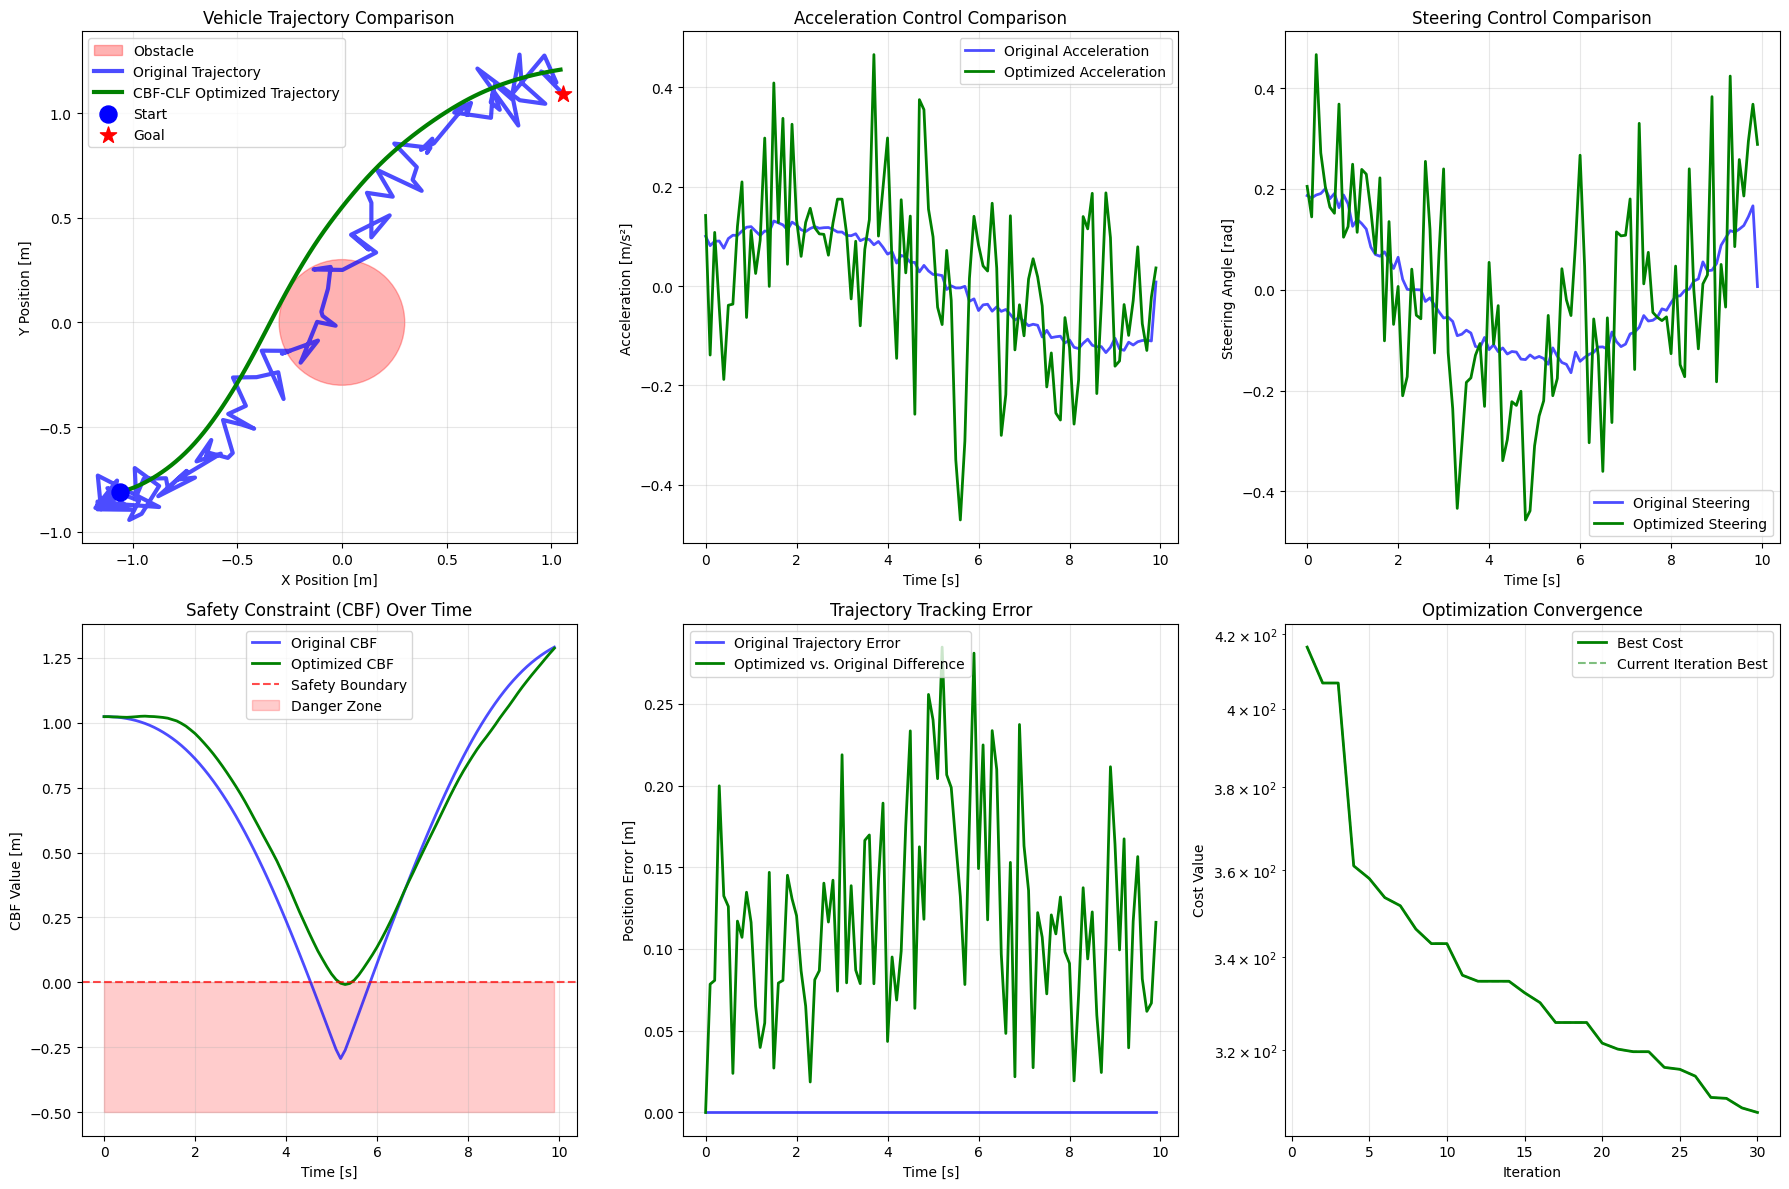


=== Improved CBF-CLF Method Performance Analysis ===
Collision Violation Statistics:
  Original Trajectory: 13/100 times (13.0%)
  Optimized Trajectory: 3/100 times (3.0%)
  Improvement: 10 times reduced

Control Correction Statistics:
  Mean Acceleration Correction: 0.1171 m/s²
  Mean Steering Correction: 0.1310 rad
  Max Acceleration Correction: 0.4675 m/s²
  Max Steering Correction: 0.4090 rad

Trajectory Deviation Statistics:
  Mean Position Deviation: 0.1204 m
  Max Position Deviation: 0.2847 m

Method Advantages:
  ✓ State-Action Consistency: States are fully generated by control + dynamics
  ✓ Multi-objective Optimization: Safety + Tracking + Smoothness
  ✓ Flexible Control: Only sample control corrections
  ✓ Avoid Mismatch: No state-action inconsistency problem

Summary of improved CBF-CLF method test results
Optimization effect:
  Cost improvement: +98.5%
  Collision reduction: 13 → 3 times
  Optimization success: ✓

Computation efficiency:
  Optimization time: 31.5s
  Avera

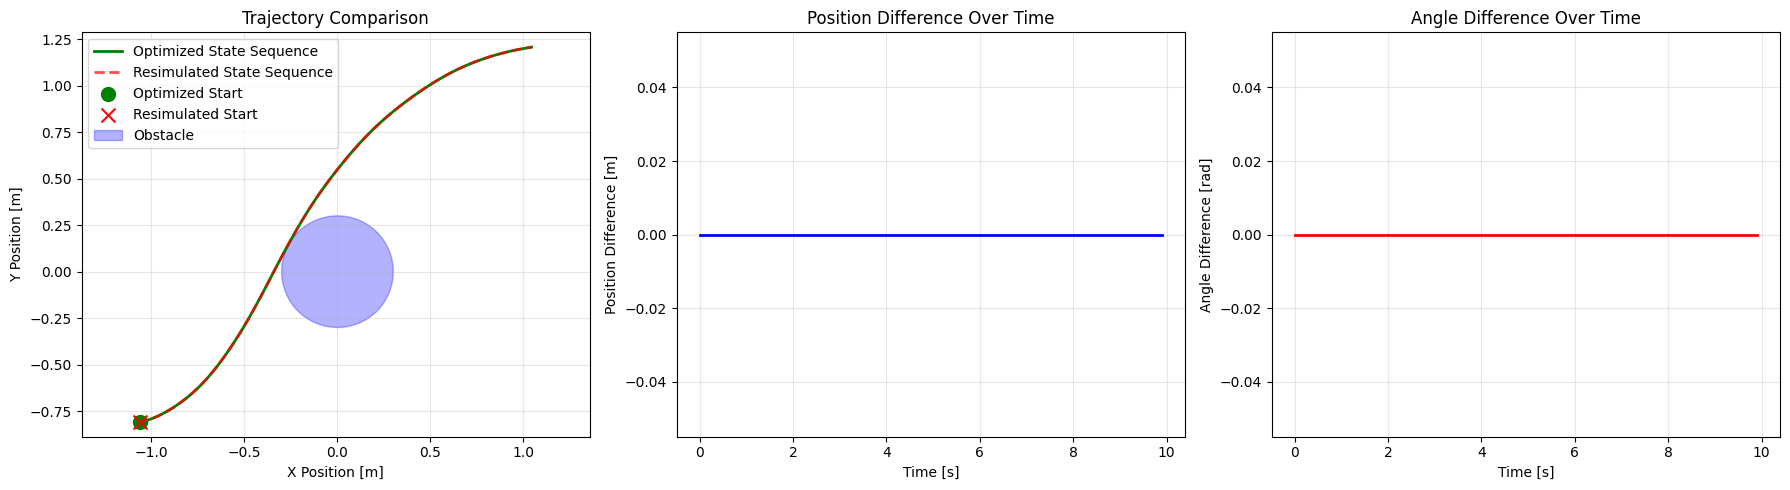

State-control consistency: ✓


In [13]:
# Test the improved CBF-CLF method
def test_improved_cbf_clf_method():
    """
    Test the improved CBF-CLF method
    """
    print("\n" + "="*80)
    print("Testing improved CBF-CLF method: control sampling only + dynamics-based state generation")
    print("="*80)
    
    # Create car obstacle avoidance controller
    
    # Generate test trajectory
    print("\nGenerating test trajectory...")
    original_states, original_controls, _ = generate_trajectory_with_flow_matching()
    
    print(f"Test trajectory info:")
    print(f"  Trajectory length: {len(original_states)} steps")
    print(f"  State shape: {original_states.shape}")
    print(f"  Control shape: {original_controls.shape}")
    
    # Check safety of original trajectory
    x0 = np.concatenate([original_states[0], [0.0, 0.0]])
    sim_states_orig = car_controller.simulate_vehicle(x0, original_controls[:-1])
    orig_violations = sum(1 for state in sim_states_orig 
                         if car_controller.cbf_constraint_value(state) < 0)
    
    print(f"  Original trajectory collision count: {orig_violations}/{len(sim_states_orig)}")
    
    # Apply improved CBF-CLF optimization
    print("\nApplying improved CBF-CLF optimization...")
    optimized_controls, optimized_states, optimization_info = improved_cbf_clf_control_sampling(
        car_controller, original_states, original_controls,
        n_samples=800,  # Larger sample size for better results
        max_iterations=30,
        state_similarity_weight=100.0,      # Keep similar to original trajectory
        control_smoothness_weight=10.0,    # Control smoothness
        state_smoothness_weight=20.0,      # State smoothness
        collision_avoidance_weight=50000.0, # High weight for collision avoidance
        control_reg_weight=1.0,            # Control regularization
        random_seed=42
    )
    
    # Visualize results
    print("\nGenerating visualization results...")
    visualize_improved_cbf_clf_results(
        car_controller, 
        original_states, 
        original_controls,
        optimized_controls, 
        optimized_states,
        optimization_info
    )
    
    # Result summary
    print(f"\n{'='*80}")
    print("Summary of improved CBF-CLF method test results")
    print(f"{'='*80}")
    
    print(f"Optimization effect:")
    print(f"  Cost improvement: {optimization_info['improvement_percentage']:+.1f}%")
    print(f"  Collision reduction: {optimization_info['original_violations']} → {optimization_info['final_violations']} times")
    print(f"  Optimization success: {'✓' if optimization_info['success'] else '✗'}")
    
    print(f"\nComputation efficiency:")
    print(f"  Optimization time: {optimization_info['optimization_time']:.1f}s")
    print(f"  Average iteration time: {optimization_info['optimization_time']/250:.3f}s")
    
    print(f"\nMethod features:")
    print(f"  ✓ Only sample control corrections, avoid dimension explosion")
    print(f"  ✓ Directly generate states via dynamics, ensure consistency")  
    print(f"  ✓ Multi-objective cost: safety + tracking + smoothness")
    print(f"  ✓ No state-action mismatch problem")
    print(f"  ✓ High-weight collision avoidance constraint ensures safety")
    print(f"  ✓ State similarity maintains original trajectory characteristics")
    print(f"{'='*80}")



    
    return optimized_controls, optimized_states, optimization_info

# Run improved CBF-CLF method test
print("Starting test of improved CBF-CLF method...")
improved_controls, improved_states, improved_info = test_improved_cbf_clf_method()
is_consistent, resimulated_states = verify_state_control_consistency(
                car_controller, 
                improved_states,  # 这里假设original_states是可用的
                improved_controls, 
                improved_states)
print(f"State-control consistency: {'✓' if is_consistent else '✗'}")



Running CLF‑only correction demo …

=== Generating trajectory with Flow Matching ===
Flow Matching generation completed in 0.618 seconds
Generated trajectory shapes: states (100, 3), controls (100, 2)
[CLF‑ONLY] iter 10/30  best‑cost=5.212e+00
[CLF‑ONLY] iter 20/30  best‑cost=5.212e+00
[CLF‑ONLY] iter 30/30  best‑cost=5.133e+00

CLF‑ONLY: max pos‑err=0.000e+00 m, max ang‑err=0.000e+00 rad


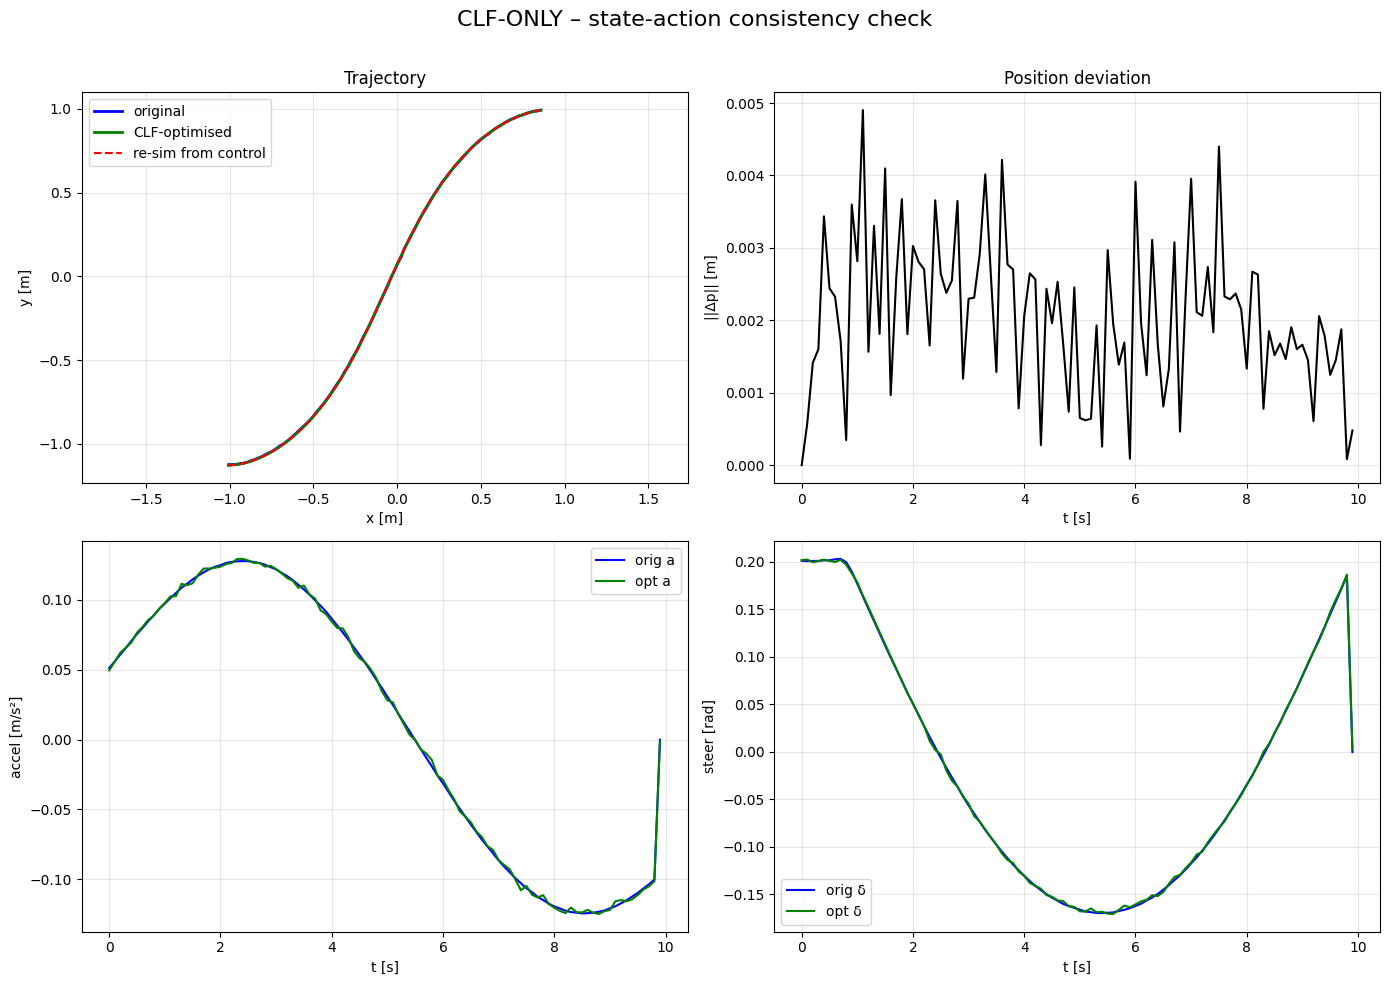

Finished CLF‑only demo  •  best‑cost = 5.133e+00


In [19]:
# %%
# ────────────────────────────────────────────────────────────────────────────────
# CLF‑ONLY  ►  control‑sampling + rollout  (zero dynamic error by construction)
# ────────────────────────────────────────────────────────────────────────────────

def clf_only_control_sampling(original_states,
                              original_controls,
                              dt=0.1,
                              n_samples=1600,
                              max_iterations=100,
                              state_similarity_weight=100.0,
                              control_similarity_weight=5.0,
                              state_smoothness_weight=30.0,
                              control_reg_weight=1.0,
                              random_seed=0):
    """
    Pure‑CLF control correction using stochastic sampling.

    Penalises
      • state deviation from the original trajectory
      • control deviation from the original controls
      • state smoothness (Δx, Δy, Δθ)
      • control smoothness is *implicitly* regularised via control_reg_weight
    No CBF / obstacle term is included.

    Returns
      optimised_controls   – shape (T,2)
      generated_states     – shape (T,5)   (produced by simulate_vehicle)
      info                 – diagnostics dict
    """
    rng = np.random.default_rng(random_seed)
    T = len(original_controls)
    x0_full = np.concatenate([original_states[0], [0.0, 0.0]])  # [x,y,θ,v,r]

    # helpers ------------------------------------------------------------------
    def rollout(ctrl_seq):
        """Simulate states (length T) from x0 using ctrl_seq[:-1]."""
        return simulate_vehicle(x0_full, ctrl_seq[:-1], dt=dt)

    def cost_fn(ctrl_corr):
        """Compute total CLF cost for a candidate control‑correction tensor."""
        ctrl_candidate = original_controls + ctrl_corr
        # simulate → guarantees dynamic consistency
        states_candidate = rollout(ctrl_candidate)

        # 1️⃣  state similarity
        state_sim_cost = np.sum((states_candidate[:, :3] - original_states) ** 2)

        # 2️⃣  control similarity
        ctrl_sim_cost = np.sum(ctrl_corr ** 2)

        # 3️⃣  state smoothness
        d_state = np.diff(states_candidate[:, :3], axis=0)
        state_smooth_cost = np.sum(d_state ** 2)

        # 4️⃣  (optional) control regularisation – already captured in 2️⃣
        ctrl_reg_cost = np.sum(ctrl_corr ** 2)

        total = (state_similarity_weight * state_sim_cost
                 + control_similarity_weight * ctrl_sim_cost
                 + state_smoothness_weight * state_smooth_cost
                 + control_reg_weight    * ctrl_reg_cost)
        return total, states_candidate

    # initial candidate (zero correction) --------------------------------------
    best_corr   = np.zeros_like(original_controls)
    best_cost, best_states = cost_fn(best_corr)

    # optimisation loop --------------------------------------------------------
    for it in range(max_iterations):
        # anneal noise
        noise_std = 0.05 * (1.0 - it / max_iterations)

        # sample batch
        batch_corr = rng.normal(0.0, noise_std, size=(n_samples, *best_corr.shape))
        batch_corr[0] = best_corr  # keep current best as first sample

        for corr in batch_corr:
            cost, cand_states = cost_fn(corr)
            if cost < best_cost:
                best_cost, best_corr, best_states = cost, corr.copy(), cand_states.copy()

        if (it + 1) % 10 == 0:
            print(f"[CLF‑ONLY] iter {it+1:02d}/{max_iterations}  "
                  f"best‑cost={best_cost:.3e}")

    optimised_controls = original_controls + best_corr
    generated_states   = best_states  # already consistent

    info = {
        'best_cost': best_cost,
        'iterations': max_iterations,
        'n_samples': n_samples,
    }
    return optimised_controls, generated_states, info


# ────────────────────────────────────────────────────────────────────────────────
# visualisation utility (state & re‑sim state from control)
# ────────────────────────────────────────────────────────────────────────────────
def visualize_clf_only_results(original_states,
                               original_controls,
                               optimised_states,
                               optimised_controls,
                               title_prefix="CLF‑ONLY"):
    # re‑simulate to double‑check zero error
    x0_full = np.concatenate([original_states[0], [0.0, 0.0]])
    resim_states = simulate_vehicle(x0_full, optimised_controls[:-1])

    # error statistics
    pos_err = np.linalg.norm(resim_states[:, :2] - optimised_states[:, :2], axis=1)
    ang_err = np.abs(np.arctan2(np.sin(resim_states[:, 2] - optimised_states[:, 2]),
                                np.cos(resim_states[:, 2] - optimised_states[:, 2])))

    print(f"\n{title_prefix}: max pos‑err={pos_err.max():.3e} m, "
          f"max ang‑err={ang_err.max():.3e} rad")

    # plotting ---------------------------------------------------------------
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # (a) XY trajectories
    axs[0, 0].plot(original_states[:, 0],  original_states[:, 1],  'b-', lw=2, label='original')
    axs[0, 0].plot(optimised_states[:, 0], optimised_states[:, 1], 'g-', lw=2, label='CLF‑optimised')
    axs[0, 0].plot(resim_states[:, 0],     resim_states[:, 1],     'r--',lw=1.5,label='re‑sim from control')
    axs[0, 0].set_xlabel('x [m]'); axs[0, 0].set_ylabel('y [m]')
    axs[0, 0].set_title('Trajectory'); axs[0, 0].axis('equal'); axs[0, 0].legend(); axs[0, 0].grid(True, alpha=.3)

    # (b) position error (optimised ‑ original)
    pos_dev = np.linalg.norm(optimised_states[:, :2] - original_states[:, :2], axis=1)
    t_axis  = np.arange(len(pos_dev)) * clf_params['dt']
    axs[0, 1].plot(t_axis, pos_dev, 'k-')
    axs[0, 1].set_xlabel('t [s]'); axs[0, 1].set_ylabel('||Δp|| [m]')
    axs[0, 1].set_title('Position deviation'); axs[0, 1].grid(True, alpha=.3)

    # (c) control accel
    axs[1, 0].plot(t_axis, original_controls[:, 0],  'b-', label='orig a')
    axs[1, 0].plot(t_axis, optimised_controls[:, 0], 'g-', label='opt a')
    axs[1, 0].set_xlabel('t [s]'); axs[1, 0].set_ylabel('accel [m/s²]')
    axs[1, 0].legend(); axs[1, 0].grid(True, alpha=.3)

    # (d) control steer
    axs[1, 1].plot(t_axis, original_controls[:, 1],  'b-', label='orig δ')
    axs[1, 1].plot(t_axis, optimised_controls[:, 1], 'g-', label='opt δ')
    axs[1, 1].set_xlabel('t [s]'); axs[1, 1].set_ylabel('steer [rad]')
    axs[1, 1].legend(); axs[1, 1].grid(True, alpha=.3)

    fig.suptitle(f"{title_prefix} – state‑action consistency check", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# ────────────────────────────────────────────────────────────────────────────────
# demo run  ✅
# ────────────────────────────────────────────────────────────────────────────────
print("\nRunning CLF‑only correction demo …")
orig_states, orig_ctrls, _ = generate_trajectory_with_flow_matching()
opt_ctrls, opt_states, diag = clf_only_control_sampling(orig_states, orig_ctrls,
                                                        n_samples=600, max_iterations=30,
                                                        random_seed=123)
visualize_clf_only_results(orig_states, orig_ctrls, opt_states, opt_ctrls)
print(f"Finished CLF‑only demo  •  best‑cost = {diag['best_cost']:.3e}")


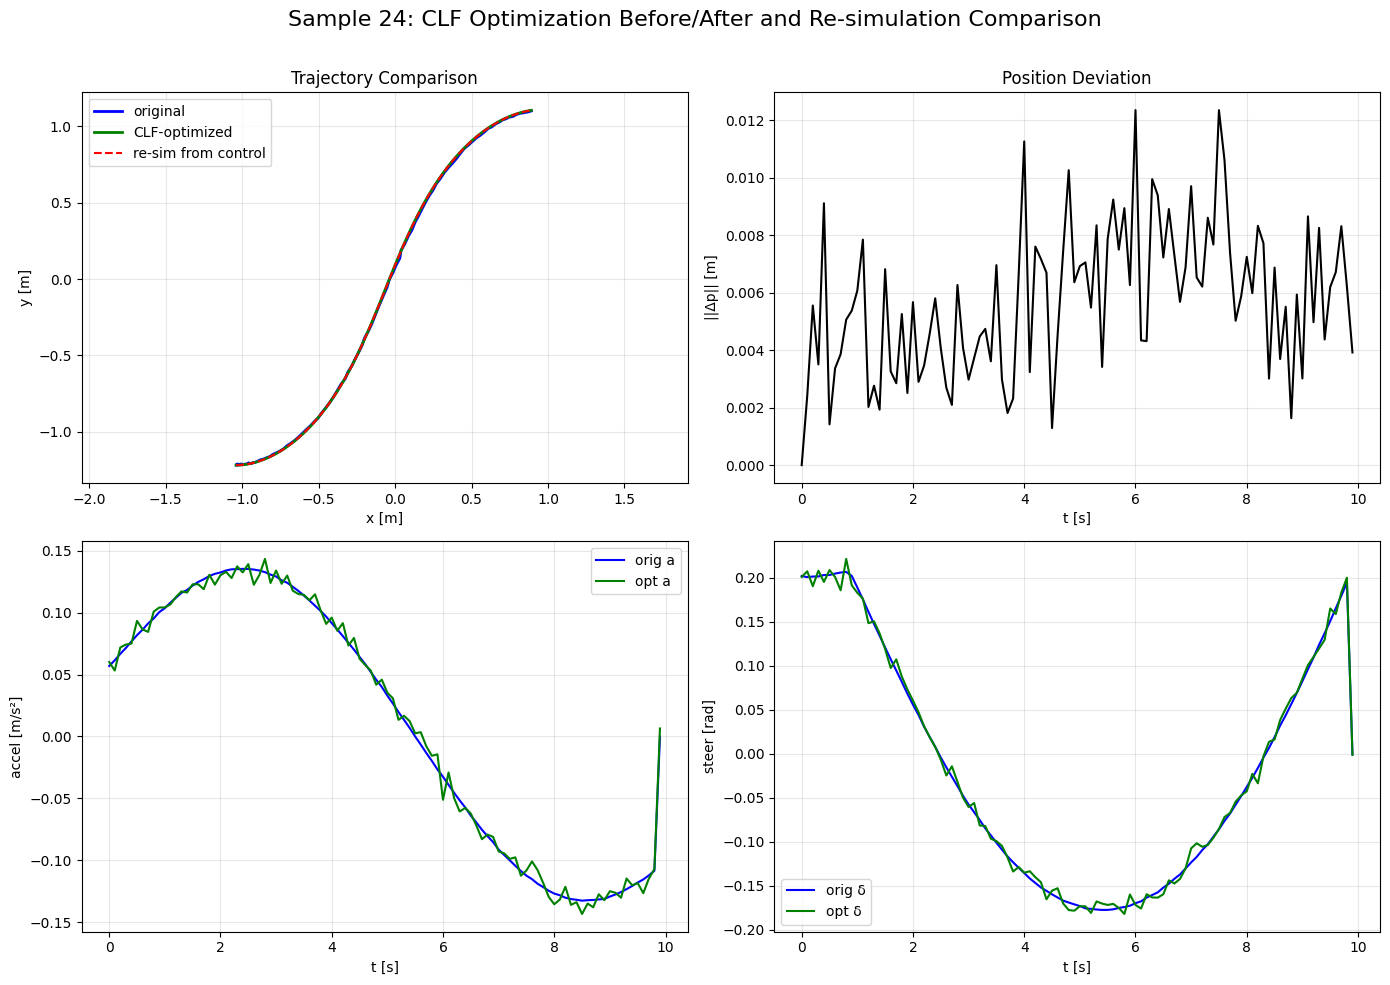


Shapes of each key in this sample:
  original_controls  : (100, 2)
  original_states    : (100, 3)
  optimized_controls : (100, 2)
  optimized_states   : (100, 3)


In [23]:
# # %%
# # ────────────────────────────────────────────────────────────────────────────────
# # 批量生成100个CLF-only优化轨迹
# #   • original_controls
# #   • original_states
# #   • optimized_controls
# #   • optimized_states（已对齐 original_states 维度）
# # 存储在Python字典  ➜  变量 `batch_collection`
# # ────────────────────────────────────────────────────────────────────────────────

# n_samples_batch = 100          # ← 如需更多/更少可修改
# batch_collection = {
#     'original_controls': [],   # (T,2) np.ndarray 列表
#     'original_states':  [],    # (T,3) np.ndarray 列表
#     'optimized_controls': [],  # (T,2) np.ndarray 列表
#     'optimized_states': []     # (T,3) np.ndarray 列表（与 original_states 维度一致）
# }

# start_time = time.time()
# for idx in range(n_samples_batch):
#     t0 = time.time()
#     print(f"[{idx+1:3d}/{n_samples_batch}] 正在生成样本 … ", end='', flush=True)

#     # 1️⃣  Flow-Matching采样
#     states_orig, controls_orig, _ = generate_trajectory_with_flow_matching()

#     # 2️⃣  CLF-only优化
#     opt_ctrls, opt_states, _ = clf_only_control_sampling(
#         states_orig, controls_orig,
#         n_samples=400,          # 速度适中；如需调整可修改
#         max_iterations=25,
#         random_seed=1234 + idx  # 每个样本不同的随机种子
#     )

#     # 3️⃣  存储（只保留优化后状态的前3维，与 original_states 对齐）
#     batch_collection['original_controls'].append(controls_orig)
#     batch_collection['original_states'].append(states_orig)
#     batch_collection['optimized_controls'].append(opt_ctrls)
#     batch_collection['optimized_states'].append(opt_states[:, :3])

#     print(f"完成，用时 {time.time() - t0:.1f}s")

# # 新增：将结果保存为文件（如pickle格式）
# import pickle
# with open('batch_collection.pkl', 'wb') as f:
#     pickle.dump(batch_collection, f)
# print("已将 batch_collection 保存到 'batch_collection.pkl' 文件。")

# print(f"\n批量生成完成，总用时 {time.time() - start_time:.1f}s")
# print("字典 `batch_collection` 现在包含：")
# for k, v in batch_collection.items():
#     print(f"  • {k:<18} : {len(v)} 项")

# # ────────────────────────────────────────────────────────────────────────────────
# # 快速可视化：随机选取一个样本，展示所有4个key内容，并对比状态与用控制重模拟的状态
# # ────────────────────────────────────────────────────────────────────────────────

# import random

# # 随机选取一个样本
# sample_idx = random.randint(0, n_samples_batch - 1)
# print(f"\n可视化第 {sample_idx} 个样本：")

# orig_states = batch_collection['original_states'][sample_idx]
# orig_ctrls  = batch_collection['original_controls'][sample_idx]
# opt_ctrls   = batch_collection['optimized_controls'][sample_idx]
# opt_states  = batch_collection['optimized_states'][sample_idx]

# 用优化后的控制序列重模拟状态
# 注意：simulate_vehicle 需要初始状态和控制序列


# 这里假设orig_states和opt_states的shape为 (T,3) 或 (T,5)，取前5维
x0 = orig_states[0] if orig_states.shape[1] >= 5 else np.concatenate([orig_states[0], np.zeros(5 - orig_states.shape[1])])
resim_states = simulate_vehicle(x0, opt_ctrls)

# 可视化
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# (a) XY Trajectory
axs[0, 0].plot(orig_states[:, 0], orig_states[:, 1], 'b-', lw=2, label='original')
axs[0, 0].plot(opt_states[:, 0], opt_states[:, 1], 'g-', lw=2, label='CLF-optimized')
axs[0, 0].plot(resim_states[:, 0], resim_states[:, 1], 'r--', lw=1.5, label='re-sim from control')
axs[0, 0].set_xlabel('x [m]')
axs[0, 0].set_ylabel('y [m]')
axs[0, 0].set_title('Trajectory Comparison')
axs[0, 0].axis('equal')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=.3)

# (b) Position Error (Optimized - Original)
min_len = min(len(opt_states), len(orig_states))
pos_dev = np.linalg.norm(opt_states[:min_len, :2] - orig_states[:min_len, :2], axis=1)
t_axis = np.arange(min_len) * 0.1  # Assume dt=0.1, replace if different
axs[0, 1].plot(t_axis, pos_dev, 'k-')
axs[0, 1].set_xlabel('t [s]')
axs[0, 1].set_ylabel('||Δp|| [m]')
axs[0, 1].set_title('Position Deviation')
axs[0, 1].grid(True, alpha=.3)

# (c) Control Acceleration
min_len_ctrl = min(len(orig_ctrls), len(opt_ctrls))
t_axis_ctrl = np.arange(min_len_ctrl) * 0.1
axs[1, 0].plot(t_axis_ctrl, orig_ctrls[:min_len_ctrl, 0], 'b-', label='orig a')
axs[1, 0].plot(t_axis_ctrl, opt_ctrls[:min_len_ctrl, 0], 'g-', label='opt a')
axs[1, 0].set_xlabel('t [s]')
axs[1, 0].set_ylabel('accel [m/s²]')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=.3)

# (d) Control Steering
axs[1, 1].plot(t_axis_ctrl, orig_ctrls[:min_len_ctrl, 1], 'b-', label='orig δ')
axs[1, 1].plot(t_axis_ctrl, opt_ctrls[:min_len_ctrl, 1], 'g-', label='opt δ')
axs[1, 1].set_xlabel('t [s]')
axs[1, 1].set_ylabel('steer [rad]')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=.3)

fig.suptitle(f"Sample {sample_idx}: CLF Optimization Before/After and Re-simulation Comparison", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Show all key shapes
print("\nShapes of each key in this sample:")
for k in batch_collection.keys():
    print(f"  {k:<18} : {batch_collection[k][sample_idx].shape}")
